In [1]:

import numpy as np
import torch
from torch import nn
from torch.utils.data import random_split

from tqdm.auto import tqdm

from xaikd import models, datasets, utils

from matplotlib import pyplot as plt

In [2]:
DATA_SIZE = 0.1

DEVICE = utils.get_device()
DATASET_NAME = "imagenet-butterfly-vs-others"

In [3]:
dataset = datasets.construct(DATASET_NAME)

ds_train = dataset.create_subset(train_split=True)
trng = torch.Generator()
trng.manual_seed(1)

ds_train, _ = random_split(ds_train, [DATA_SIZE, 1-DATA_SIZE])

In [4]:
dl_train = datasets.build_dataloader(ds_train, shuffle=False)

In [5]:
len(dl_train)

2002

In [6]:
logodd_layer = models.layers.LayerLogOddSelectedClasses(
    selected_classes=dataset.selected_classes
)

  0%|          | 0/2002 [00:00<?, ?it/s]

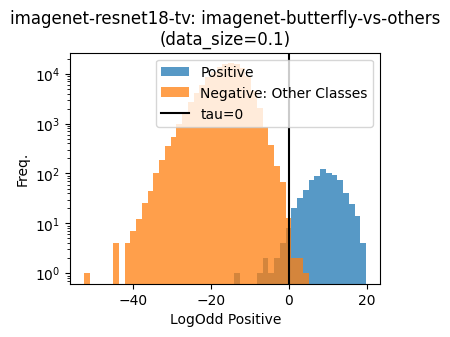

In [7]:
@torch.no_grad()
def compute_logit_distribution(model_name, verbose=False):
    dl =  dl_train

    model = nn.Sequential(
        models.get_trained_model(model_name),
        logodd_layer, 
    )
    model = model.eval().to(DEVICE)

    arr_logits = []
    arr_y = []
    for x, y in tqdm(dl, disable=not verbose):
        x = x.to(DEVICE)
        logit = model(x).cpu()
        arr_y.extend(y.detach().numpy().tolist())
        arr_logits.extend(logit.detach().numpy().tolist())

    arr_logits = np.array(arr_logits) 
    arr_y = np.array(arr_y)
    plt.figure(figsize=(4, 3))
    plt.title(f"{model_name}: {DATASET_NAME}\n(data_size={DATA_SIZE})")
    vmin, vmax = np.min(arr_logits), np.max(arr_logits)
    bins = np.linspace(vmin, vmax, 50)
    
    plt.hist(
        arr_logits[arr_y == 1],
        bins=bins,
        label=f"Positive",
        alpha=0.75
    )
    plt.hist(
        arr_logits[arr_y == 0],
        bins=bins,
        label=f"Negative: Other Classes",
        alpha=0.75
    )
    tau = 0
    plt.axvline(tau, label=f"tau={tau}", color="black")
    plt.ylabel("Freq.")
    plt.xlabel(f"LogOdd Positive")
    plt.legend()
    plt.yscale("log")
    
compute_logit_distribution(
    model_name="imagenet-resnet18-tv", 
    verbose=True
)    

  0%|          | 0/2002 [00:00<?, ?it/s]

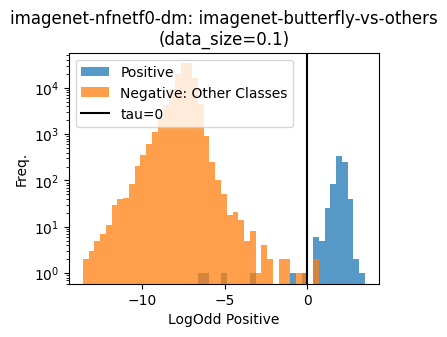

In [8]:
compute_logit_distribution(
    model_name="imagenet-nfnetf0-dm", 
    verbose=True
)    

  0%|          | 0/2002 [00:00<?, ?it/s]

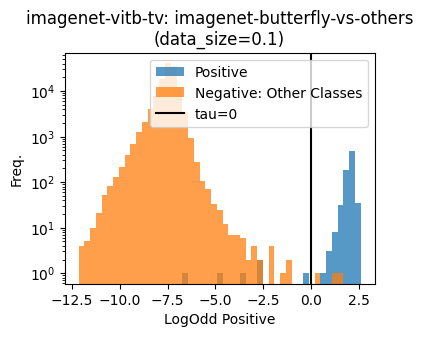

In [9]:
compute_logit_distribution(
    model_name="imagenet-vitb-tv", 
    verbose=True
)    